# Ejercicio PCA (Principal Component Analysis)
En este ejercicio vas a trabajar con un dataset de información de ciudadanos como el estado civil, número de hijos, qué gastos e ingresos tiene, etc...

Se cuenta con un target, que es si el ciudadano va a alquilar o a comprar una vivienda. Para ello,  con PCA

### Importamos librerias
Principales librerías que usarás durante el notebook.

In [120]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
# ==============================================================================
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import scale
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Pipeline
# ==============================================================================
from sklearn.pipeline import Pipeline

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

### Cargamos datos de entrada
1. Carga el csv *comprar_alquilar.csv*
2. Obtén la información básica: columnas, dimensiones, descripción de las variables, missings...

In [21]:
df_comprar_alquilar = pd.read_csv("data/comprar_alquilar.csv")
df_comprar_alquilar.head()

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1


In [22]:
df_comprar_alquilar.shape

(202, 10)

In [23]:
df_comprar_alquilar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ingresos        202 non-null    int64
 1   gastos_comunes  202 non-null    int64
 2   pago_coche      202 non-null    int64
 3   gastos_otros    202 non-null    int64
 4   ahorros         202 non-null    int64
 5   vivienda        202 non-null    int64
 6   estado_civil    202 non-null    int64
 7   hijos           202 non-null    int64
 8   trabajo         202 non-null    int64
 9   comprar         202 non-null    int64
dtypes: int64(10)
memory usage: 15.9 KB


In [24]:
df_comprar_alquilar.describe()

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000
mean,4958.995050,971.584158,211.742574,515.425743,38749.668317,373349.638614,1.024752,1.232673,4.490099,0.331683
std,1682.862556,272.106351,124.940754,168.103075,17365.231870,136371.525622,0.837184,1.367833,2.535794,0.471988
min,2008.000000,384.000000,0.000000,201.000000,10319.000000,176553.000000,0.000000,0.000000,0.000000,0.000000
25%,3513.750000,766.750000,99.000000,383.250000,24964.250000,274810.000000,0.000000,0.000000,2.000000,0.000000
50%,4947.500000,968.000000,208.500000,522.500000,38523.000000,340783.500000,1.000000,1.000000,5.000000,0.000000
75%,6374.500000,1165.250000,318.750000,656.750000,52150.750000,444482.000000,2.000000,2.000000,7.000000,1.000000
max,7984.000000,1585.000000,448.000000,828.000000,69934.000000,669540.000000,2.000000,4.000000,8.000000,1.000000


In [25]:
df_comprar_alquilar["comprar"].value_counts(normalize=True)

comprar
0    0.668317
1    0.331683
Name: proportion, dtype: float64

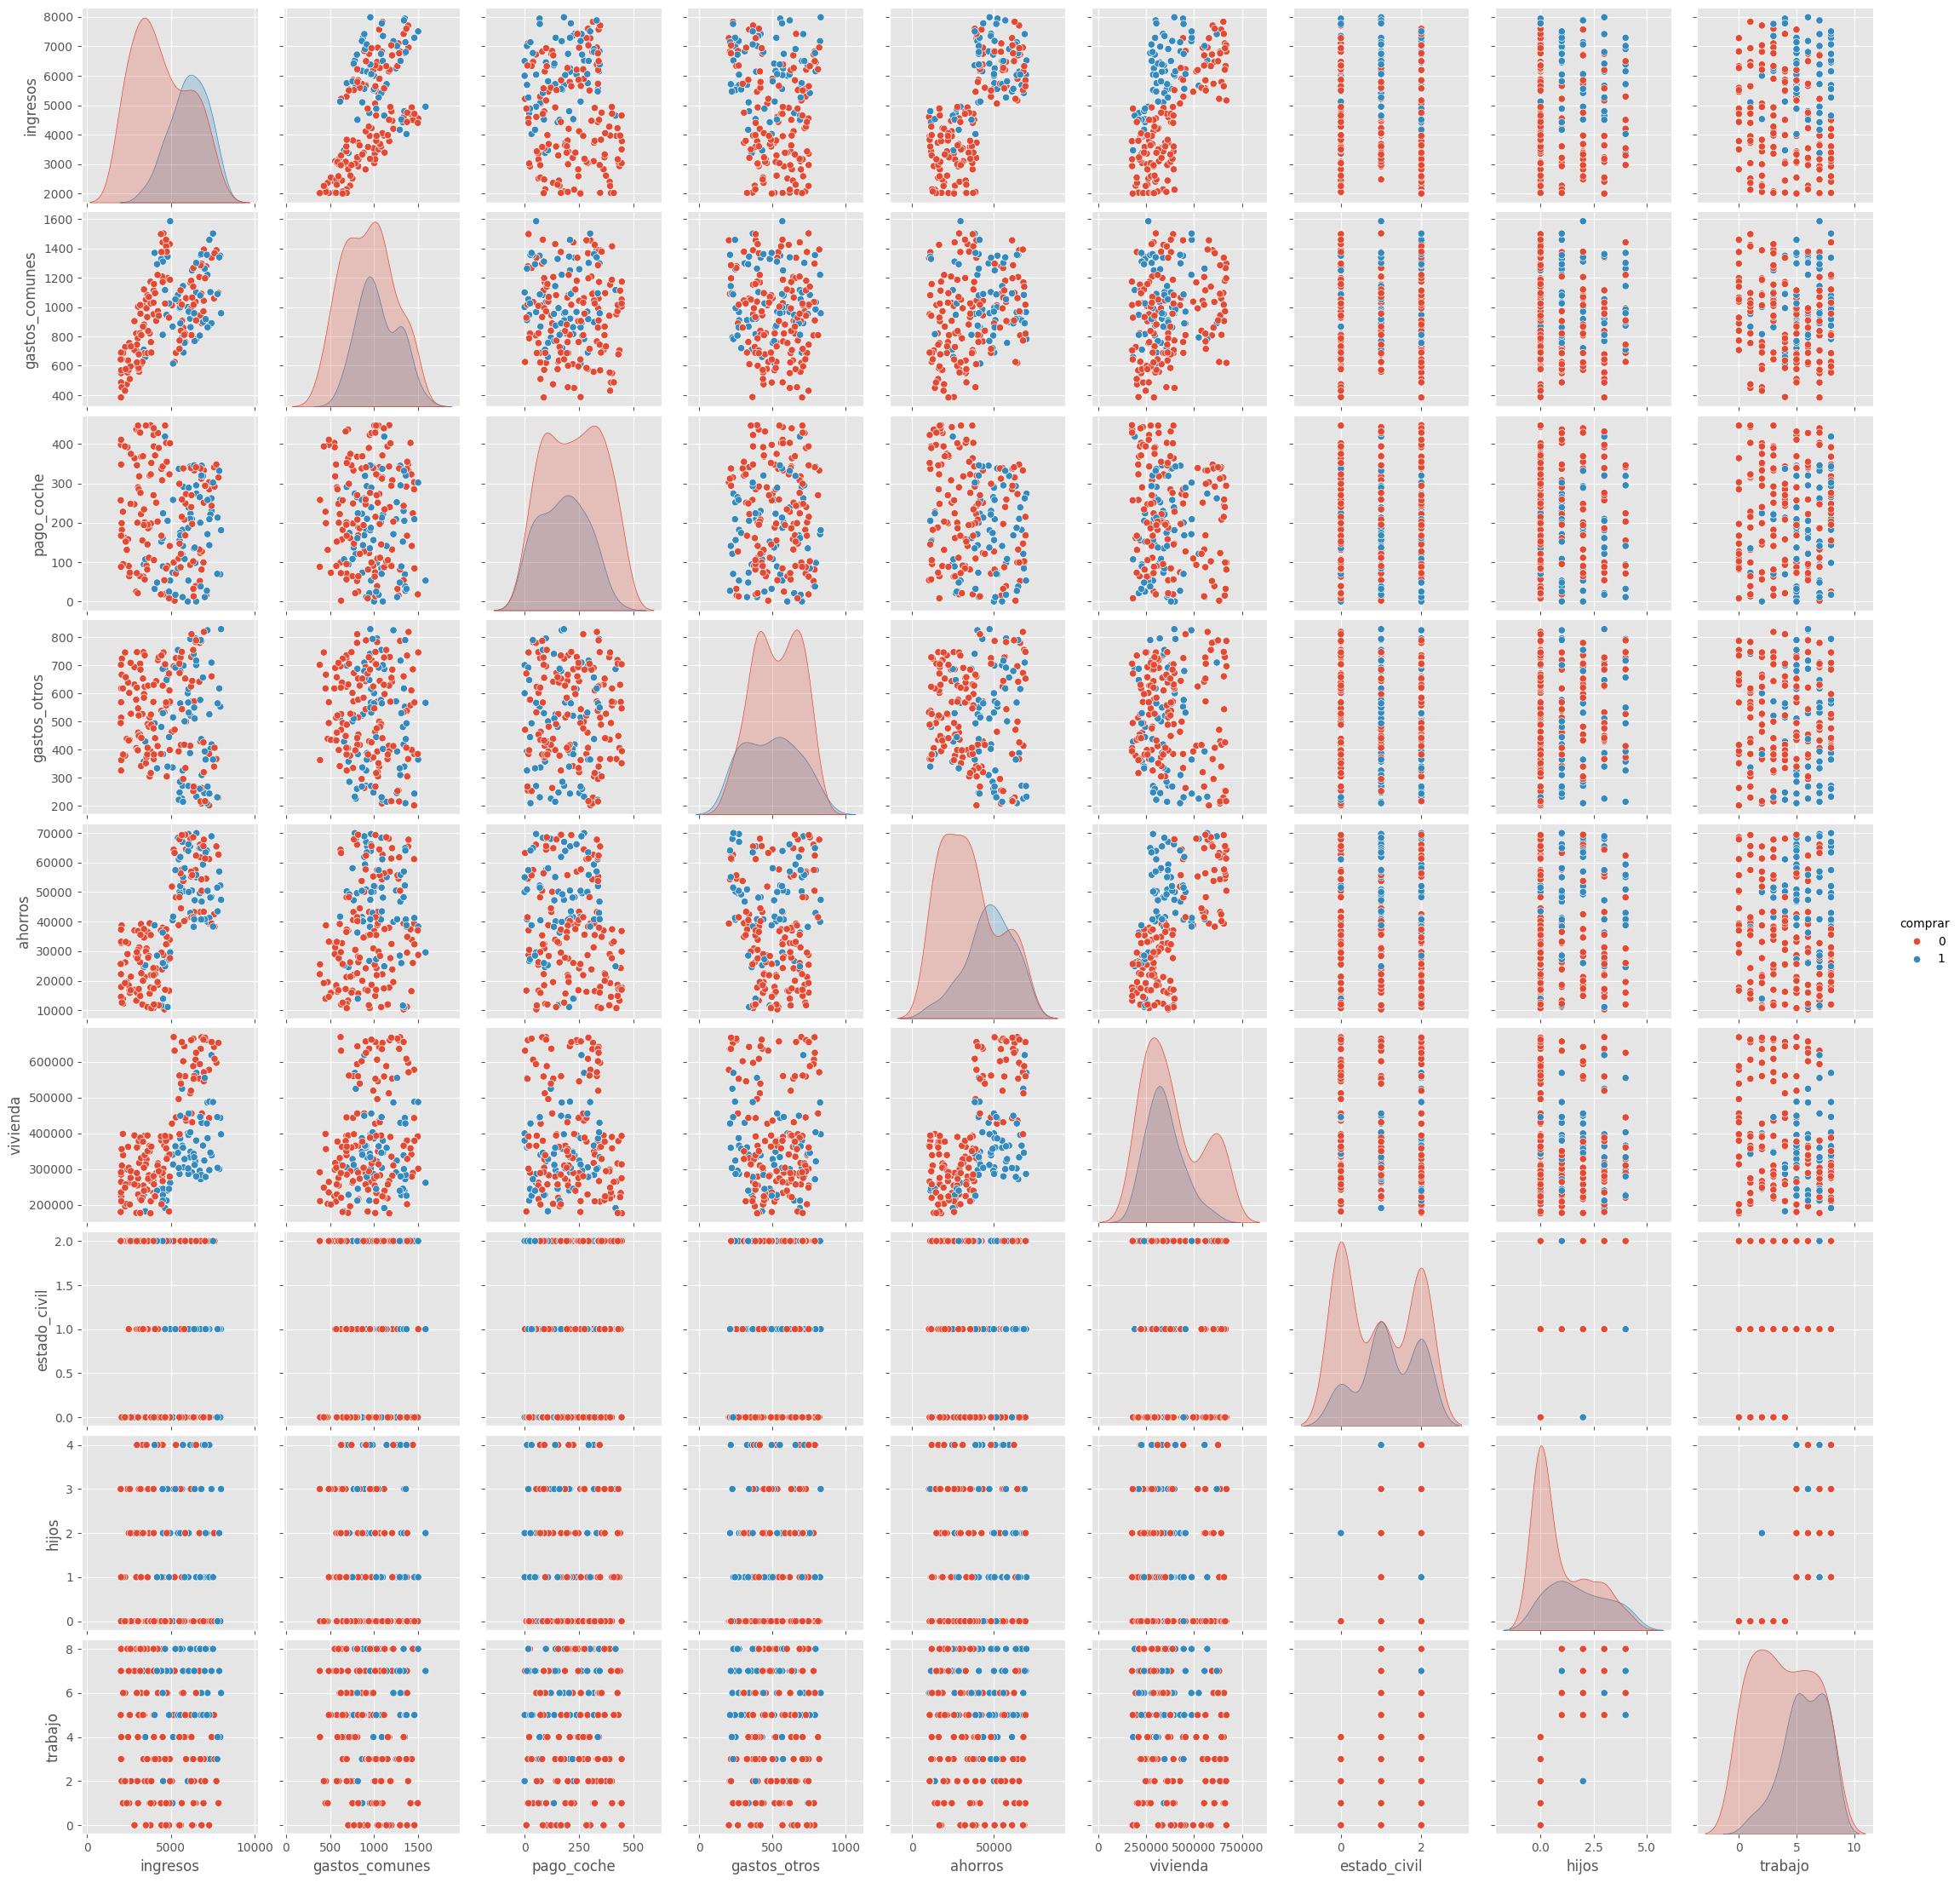

In [26]:
sns.pairplot(df_comprar_alquilar, hue="comprar")

<Axes: >

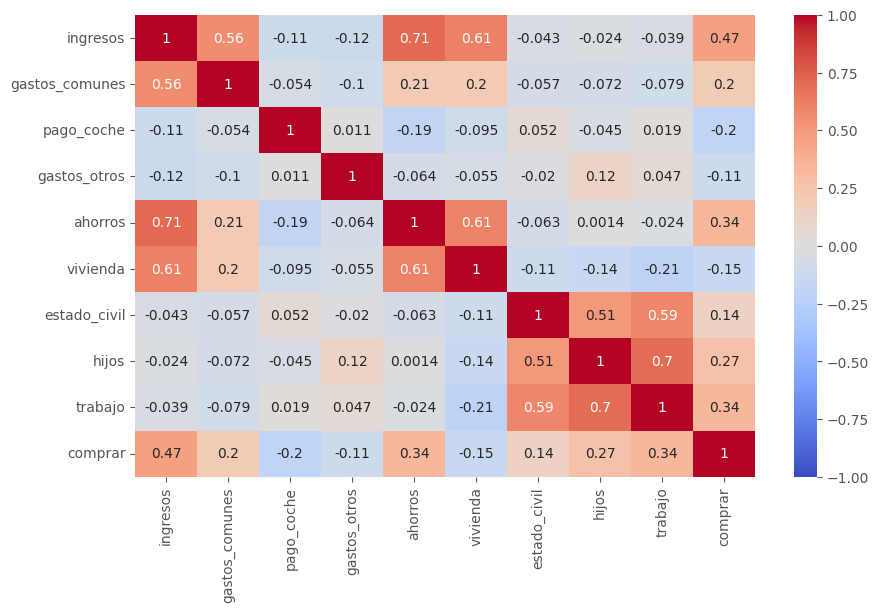

In [27]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_comprar_alquilar.corr(numeric_only=True), annot=True, cmap="coolwarm", vmin=-1)

### Visualicemos las dimensiones
Realiza un análisis univariante. Realiza la gráfica que consideres para cada variable, diferenciando por colores el target (*comprar*).

### Ingresos

In [35]:
df_comprar_alquilar.groupby("comprar")["ingresos"].mean()

comprar
0    4406.570370
1    6072.089552
Name: ingresos, dtype: float64

In [28]:
df_comprar_alquilar_copia = df_comprar_alquilar.copy()

([<matplotlib.axis.XTick at 0x1d7c0918890>,
 [Text(0, 0, 'Alquilar'), Text(1, 0, 'Comprar')])

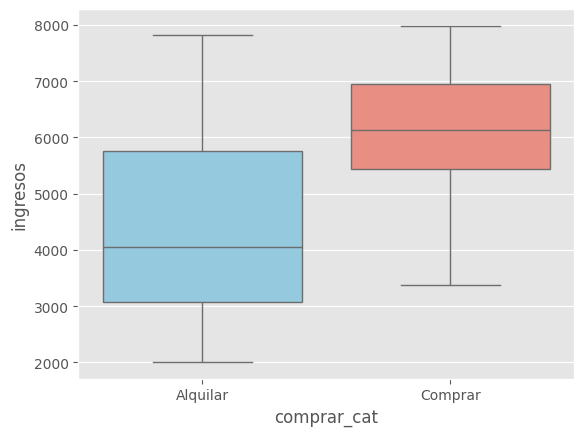

In [31]:
df_comprar_alquilar_copia['comprar_cat'] = df_comprar_alquilar_copia['comprar'].astype('category')
sns.boxplot(
    data=df_comprar_alquilar_copia,
    x='comprar_cat',
    y='ingresos',
    palette={'0':"skyblue", '1':"salmon"}
)
plt.xticks([0,1], ['Alquilar', 'Comprar'])

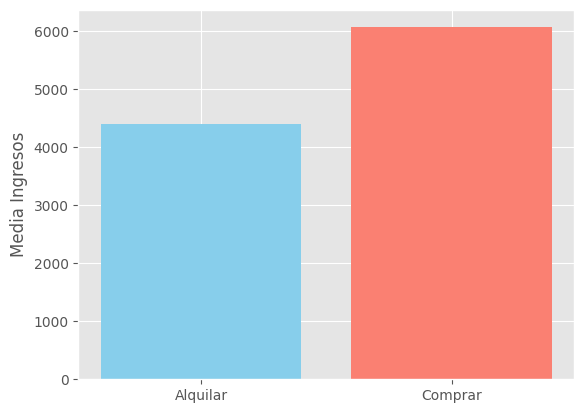

In [45]:
medias_ingresos = df_comprar_alquilar.groupby("comprar")["ingresos"].mean()
plt.bar([0,1], medias_ingresos, color=['skyblue','salmon'])
plt.xticks([0,1], ['Alquilar', 'Comprar'])
plt.ylabel("Media Ingresos")
plt.show()

### Ahorros

In [49]:
df_comprar_alquilar.groupby("comprar")["ahorros"].mean()

comprar
0    34591.088889
1    47128.895522
Name: ahorros, dtype: float64

([<matplotlib.axis.XTick at 0x1d7c21bb710>,
 [Text(0, 0, 'Alquilar'), Text(1, 0, 'Comprar')])

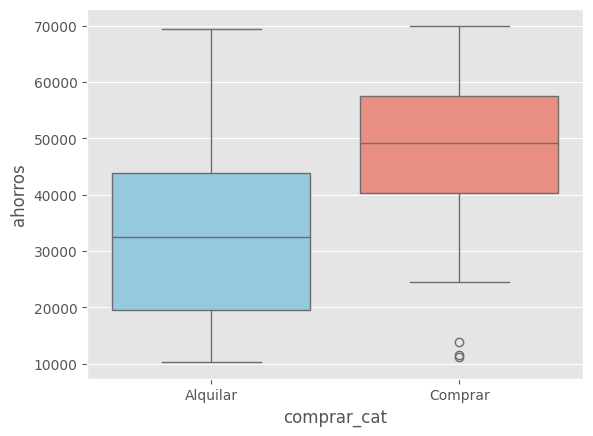

In [47]:
sns.boxplot(
    data=df_comprar_alquilar_copia,
    x='comprar_cat',
    y='ahorros',
    palette={'0':"skyblue", '1':"salmon"}
)
plt.xticks([0,1], ['Alquilar', 'Comprar'])

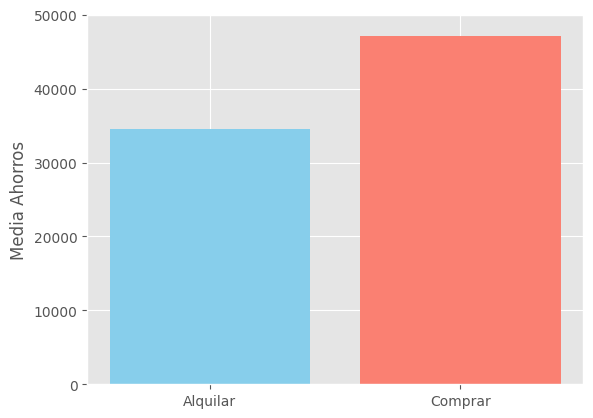

In [50]:
medias_ingresos = df_comprar_alquilar.groupby("comprar")["ahorros"].mean()
plt.bar([0,1], medias_ingresos, color=['skyblue','salmon'])
plt.xticks([0,1], ['Alquilar', 'Comprar'])
plt.ylabel("Media Ahorros")
plt.ylim(0, 50000)  # límite superior en 50.000
plt.show()

### Trabajo

In [60]:
df_comprar_alquilar.groupby("comprar")["trabajo"].value_counts()

comprar  trabajo
0        3          17
         0          16
         1          16
         2          16
         5          15
         8          15
         6          14
         7          14
         4          12
1        5          16
         8          14
         7          13
         6           9
         4           7
         3           4
         1           2
         2           2
Name: count, dtype: int64

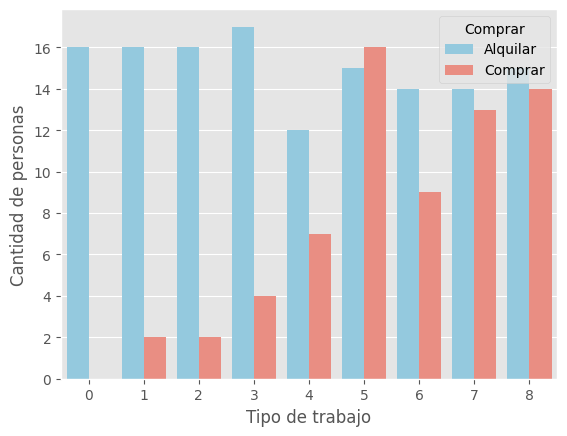

In [62]:
sns.countplot(data=df_comprar_alquilar, x="trabajo", hue="comprar", palette={0:"skyblue", 1:"salmon"})
plt.xlabel("Tipo de trabajo")
plt.ylabel("Cantidad de personas")
plt.legend(title="Comprar", labels=["Alquilar", "Comprar"])
plt.show()

## Estandariza los datos
Como el objetivo de estos primeros apartados no es encontrar el mejor modelo con el mejor accuracy, por sencillez, no es necesario dividir en train y test.

In [65]:
X = df_comprar_alquilar.drop(columns="comprar")
X

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo
0,6000,1000,0,600,50000,400000,0,2,2
1,6745,944,123,429,43240,636897,1,3,6
2,6455,1033,98,795,57463,321779,2,1,8
3,7098,1278,15,254,54506,660933,0,0,3
4,6167,863,223,520,41512,348932,0,0,3
...,...,...,...,...,...,...,...,...,...
197,3831,690,352,488,10723,363120,0,0,2
198,3961,1030,270,475,21880,280421,2,3,8
199,3184,955,276,684,35565,388025,1,3,8
200,3334,867,369,652,19985,376892,1,2,5


In [69]:
st = StandardScaler()
st.fit(X)
X_std = st.transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns)
X_std

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo
0,0.620129,0.104689,-1.698954,0.504359,0.649475,0.195910,-1.227088,0.562374,-0.984420
1,1.063927,-0.101625,-0.712042,-0.515401,0.259224,1.937370,-0.029640,1.295273,0.596915
2,0.891173,0.226266,-0.912634,1.667244,1.080309,-0.379102,1.167809,-0.170526,1.387582
3,1.274209,1.128886,-1.578599,-1.559015,0.909604,2.114062,-1.227088,-0.903426,-0.589086
4,0.719611,-0.400042,0.090326,0.027279,0.159468,-0.179497,-1.227088,-0.903426,-0.589086
...,...,...,...,...,...,...,...,...,...
197,-0.671949,-1.037402,1.125381,-0.163554,-1.617963,-0.075199,-1.227088,-0.903426,-0.984420
198,-0.594508,0.215214,0.467439,-0.241079,-0.973876,-0.683130,1.167809,1.295273,1.387582
199,-1.057368,-0.061099,0.515581,1.005294,-0.183849,0.107880,-0.029640,1.295273,1.387582
200,-0.968013,-0.385305,1.261783,0.814462,-1.083273,0.026040,-0.029640,0.562374,0.201581


## Aplicamos PCA
Aplica el algoritmo de PCA para 9 components, es decir, para todas las features

In [70]:
pca = PCA(n_components=9)
pca.fit(X_std)

,n_components,9
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [71]:
print(pca.explained_variance_ratio_)

[0.29913557 0.23294923 0.11711241 0.10685622 0.09635279 0.05629866
 0.04145579 0.03017819 0.01966115]


### Veamos cómo de buenos predictores son las nuevas dimensiones
Responde a las siguientes preguntas:
1. ¿Cuánta varianza explica cada Principal Component?

In [72]:
varianzas = np.array([
    0.29913557,
    0.23294923,
    0.11711241,
    0.10685622,
    0.09635279,
    0.05629866,
    0.04145579,
    0.03017819,
    0.01966115
])

df_var = pd.DataFrame(
    data=varianzas,
    columns=['Explicacion_varianzas'],
    index=[f'PC{i+1}' for i in range(len(varianzas))]
)

df_var

,Explicacion_varianzas
PC1,0.299136
PC2,0.232949
PC3,0.117112
PC4,0.106856
PC5,0.096353
PC6,0.056299
PC7,0.041456
PC8,0.030178
PC9,0.019661


2. ¿Y de manera acumulada empezando por el PC1?

In [74]:
df_var['Varianza_acumulada'] = df_var['Explicacion_varianzas'].cumsum()

df_var

,Explicacion_varianzas,Varianza_acumulada
PC1,0.299136,0.299136
PC2,0.232949,0.532085
PC3,0.117112,0.649197
PC4,0.106856,0.756053
PC5,0.096353,0.852406
PC6,0.056299,0.908705
PC7,0.041456,0.950161
PC8,0.030178,0.980339
PC9,0.019661,1.000000


3. ¿Cuánta varianza explicarían sólo 5 componentes?

In [76]:
df_var[["Explicacion_varianzas"]].head(5).sum()

Explicacion_varianzas    0.852406
dtype: float64

### Graficamos la variacion explicada acumulada
Representa en un diagrama de lineas la evolución de la varianza acumulada en función de los PC

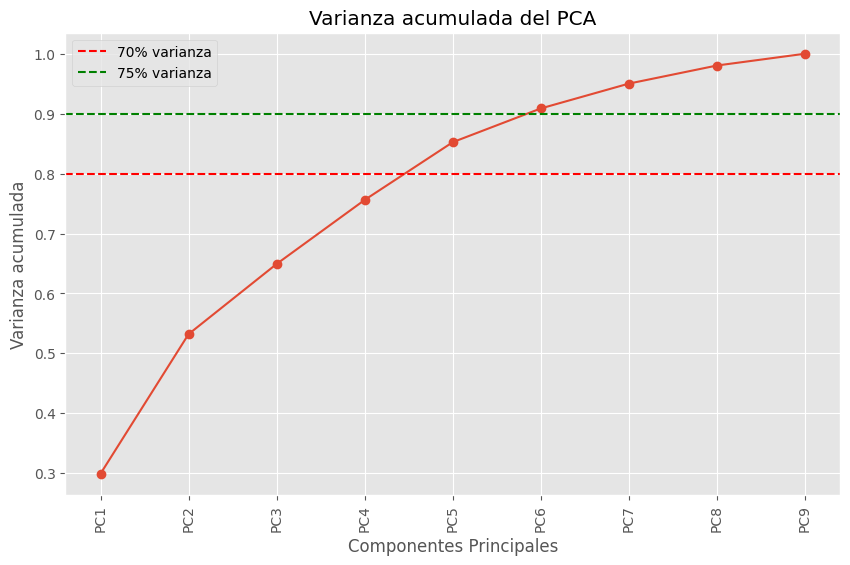

In [78]:
plt.figure(figsize=(10,6))
plt.plot(df_var.index, df_var['Varianza_acumulada'], marker='o', linestyle='-')
plt.xticks(rotation=90)
plt.xlabel('Componentes Principales')
plt.ylabel('Varianza acumulada')
plt.title('Varianza acumulada del PCA')
plt.grid(True)
plt.axhline(y=0.80, color='r', linestyle='--', label='70% varianza')
plt.axhline(y=0.90, color='g', linestyle='--', label='75% varianza')
plt.legend()
plt.show()

### Veamos la correlación entre las nuevas componentes y las dimensiones originales
Representa en un mapa de calor los PCA vs las variables originales. Esta información la puedes obtener del atributo de PCA *components_*.

In [79]:
df_pca_components = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f'PC{i+1}' for i in range(pca.components_.shape[0])]
)

df_pca_components

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo
PC1,0.493720,0.318229,-0.123771,-0.111876,0.444650,0.462609,-0.252279,-0.259859,-0.290248
PC2,0.306959,0.147373,-0.091641,0.000112,0.288435,0.148985,0.469044,0.521894,0.527156
PC3,-0.091419,-0.363453,-0.516144,0.701986,0.191767,0.140513,-0.172885,0.112184,-0.036910
PC4,0.111222,0.081630,0.780268,0.590704,0.022839,0.150085,-0.007663,0.007404,-0.007493
PC5,0.088897,0.763006,-0.265554,0.330744,-0.289002,-0.365556,-0.104639,0.043668,0.000009
PC6,-0.075477,0.067903,-0.153697,0.154422,-0.230181,0.290799,0.767070,-0.387964,-0.256446
PC7,-0.154319,0.105598,-0.027333,-0.101876,-0.524584,0.641034,-0.212365,0.460067,-0.105053
PC8,-0.012732,0.010274,-0.061759,0.037977,-0.212759,0.260847,-0.204816,-0.532216,0.745630
PC9,0.776990,-0.374440,-0.048557,0.026631,-0.474168,-0.156101,-0.003289,0.011051,-0.060657


Text(0.5, 36.58159722222221, 'Variables originales')

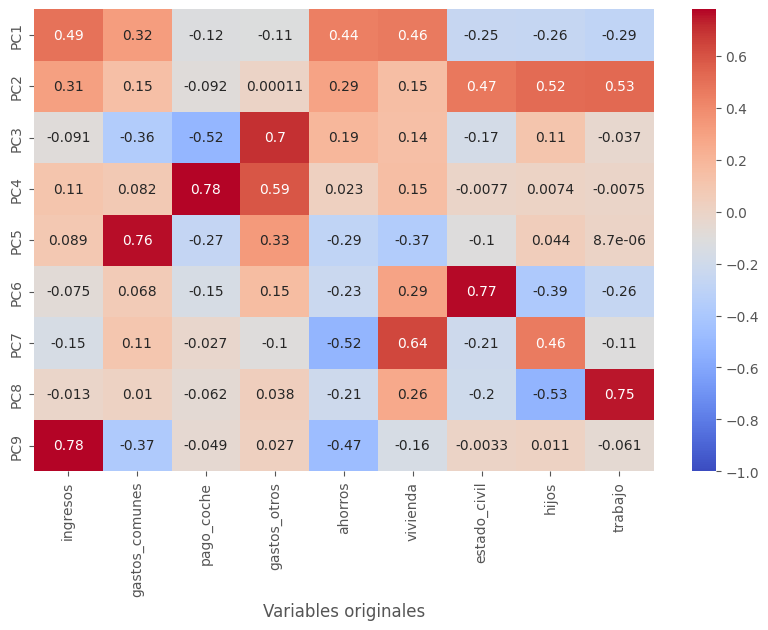

In [83]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    df_pca_components,
    cmap="coolwarm",
    annot=True,
    vmin=-1
)

plt.xlabel("Variables originales")

## Predicciones
1. Divide en train y test
2. Prepara un pipeline compuesto por:
    - StandardScaler,
    - PCA de 5 componentes
    - Un clasificador
3. Entrena
4. Predice con test
5. Calcula el accuracy score en train y test
6. Representa la matriz de confusión
7. ¿Qué combinación de parámetros y componentes mejoraría el accuracy en test?
8. Vuelve a iterar de nuevo con un gridsearch
9. Guarda tu mejor modelo

In [84]:
X_std

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo
0,0.620129,0.104689,-1.698954,0.504359,0.649475,0.195910,-1.227088,0.562374,-0.984420
1,1.063927,-0.101625,-0.712042,-0.515401,0.259224,1.937370,-0.029640,1.295273,0.596915
2,0.891173,0.226266,-0.912634,1.667244,1.080309,-0.379102,1.167809,-0.170526,1.387582
3,1.274209,1.128886,-1.578599,-1.559015,0.909604,2.114062,-1.227088,-0.903426,-0.589086
4,0.719611,-0.400042,0.090326,0.027279,0.159468,-0.179497,-1.227088,-0.903426,-0.589086
...,...,...,...,...,...,...,...,...,...
197,-0.671949,-1.037402,1.125381,-0.163554,-1.617963,-0.075199,-1.227088,-0.903426,-0.984420
198,-0.594508,0.215214,0.467439,-0.241079,-0.973876,-0.683130,1.167809,1.295273,1.387582
199,-1.057368,-0.061099,0.515581,1.005294,-0.183849,0.107880,-0.029640,1.295273,1.387582
200,-0.968013,-0.385305,1.261783,0.814462,-1.083273,0.026040,-0.029640,0.562374,0.201581


In [86]:
y = df_comprar_alquilar["comprar"]
y

0      1
1      0
2      1
3      0
4      1
      ..
197    0
198    0
199    0
200    0
201    0
Name: comprar, Length: 202, dtype: int64

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

In [128]:
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=5)),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000, solver='liblinear'))
])

In [129]:
pipe_lr.fit(X_train, y_train)

y_train_pred_lr = pipe_lr.predict(X_train)
y_test_pred_lr = pipe_lr.predict(X_test)

print("Accuracy en train: ", accuracy_score(y_train, y_train_pred_lr))
print("Accuracy en test: ", accuracy_score(y_test, y_test_pred_lr))

Accuracy en train:  0.7888198757763976
Accuracy en test:  0.7073170731707317


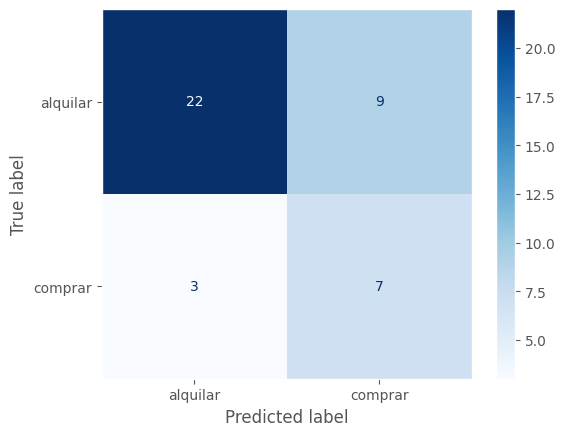

In [130]:
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["alquilar", "comprar"])
disp.plot(cmap='Blues')
plt.grid(False)
plt.show()

In [131]:
pipe_scv = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=5)),
    ("classifier", SVC(class_weight="balanced", C=0.1, kernel='rbf'))
])

In [132]:
pipe_scv.fit(X_train, y_train)

y_train_pred = pipe_scv.predict(X_train)
y_test_pred = pipe_scv.predict(X_test)

print("Accuracy en train: ", accuracy_score(y_train, y_train_pred))
print("Accuracy en test: ", accuracy_score(y_test, y_test_pred))

Accuracy en train:  0.8074534161490683
Accuracy en test:  0.7073170731707317


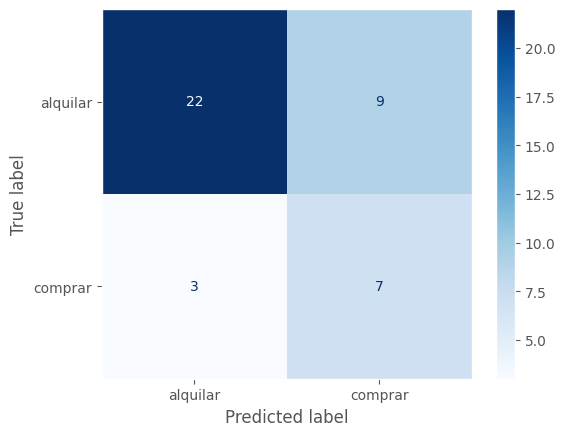

In [133]:
cm_svc = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=["alquilar", "comprar"])
disp.plot(cmap='Blues')
plt.grid(False)
plt.show()

7. ¿Qué combinación de parámetros y componentes mejoraría el accuracy en test?


Para mejorar el accuracy en test, conviene jugar con los componentes en PCA, el parámetro C y kernel del SVM.

In [143]:
pipe_scv_02 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=5)),
    ("classifier", SVC())
])

svm_params = {
    'scaler': [StandardScaler(), MinMaxScaler()],
    'classifier__class_weight': ['balanced'],
    'classifier': [SVC()],
    'classifier__C': [0.001, 0.1, 0.5, 1, 5, 10, 100],
    'classifier__kernel': ['linear', 'rbf', 'poly']
}

search_space = svm_params

clf = GridSearchCV(estimator=pipe_scv_02,
                   param_grid=search_space,
                   cv=5,
                   verbose=3,
                   n_jobs=-1,
                   scoring='accuracy')

clf.fit(X_train, y_train)

Fitting 5 folds for each of 42 candidates, totalling 210 fits


,estimator,"Pipeline(step...ier', SVC())])"
,param_grid,"{'classifier': [SVC()], 'classifier__C': [0.001, 0.1, ...], 'classifier__class_weight': ['balanced'], 'classifier__kernel': ['linear', 'rbf', ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [144]:
print(clf.best_estimator_)
print(clf.best_score_)
print(clf.best_params_)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=5)),
                ('classifier', SVC(C=100, class_weight='balanced'))])
0.8261363636363637
{'classifier': SVC(), 'classifier__C': 100, 'classifier__class_weight': 'balanced', 'classifier__kernel': 'rbf', 'scaler': StandardScaler()}


In [145]:
best_model = clf.best_estimator_

best_model.fit(X_train, y_train)

y_test_pred_clf = best_model.predict(X_test)

print("Accuracy en test: ", accuracy_score(y_test, y_test_pred_clf))

Accuracy en test:  0.7317073170731707


In [146]:
pipe_scv_03 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),  
    ("classifier", SVC())
])

svm_params = {
    'scaler': [StandardScaler(), MinMaxScaler()],
    'pca__n_components': [3, 4, 5, 6, 7, 8, 9], 
    'classifier__class_weight': ['balanced'],
    'classifier': [SVC()],
    'classifier__C': [0.001, 0.1, 0.5, 1, 5, 10, 100],
    'classifier__kernel': ['linear', 'rbf', 'poly']
}

clf_02 = GridSearchCV(
    estimator=pipe_scv_03,
    param_grid=svm_params,
    cv=5,
    verbose=3,
    n_jobs=-1,
    scoring='accuracy'
)

clf_02.fit(X_train, y_train)


Fitting 5 folds for each of 294 candidates, totalling 1470 fits


,estimator,"Pipeline(step...ier', SVC())])"
,param_grid,"{'classifier': [SVC()], 'classifier__C': [0.001, 0.1, ...], 'classifier__class_weight': ['balanced'], 'classifier__kernel': ['linear', 'rbf', ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,feature_range,"(0, ...)"


In [147]:
print(clf_02.best_estimator_)
print(clf_02.best_score_)
print(clf_02.best_params_)

Pipeline(steps=[('scaler', MinMaxScaler()), ('pca', PCA(n_components=9)),
                ('classifier',
                 SVC(C=5, class_weight='balanced', kernel='linear'))])
0.9443181818181818
{'classifier': SVC(), 'classifier__C': 5, 'classifier__class_weight': 'balanced', 'classifier__kernel': 'linear', 'pca__n_components': 9, 'scaler': MinMaxScaler()}


In [152]:
best_model_final = clf_02.best_estimator_

best_model_final.fit(X_train, y_train)

y_test_pred_clf_02 = best_model_final.predict(X_test)

print("Accuracy en test: ", accuracy_score(y_test, y_test_pred_clf_02))

Accuracy en test:  0.8780487804878049


In [153]:
import pickle

pickle.dump(best_model, open("best_model_svc.pkl", "wb"))

In [154]:
modelo_svc = pickle.load(open("best_model_svc.pkl", "rb"))
modelo_svc

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,5
,copy,True
,whiten,False
,svd_solver,'auto'
